In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [16]:
exercise_df = sns.load_dataset("exercise")
print("Exercise Data set:")
print(exercise_df)

Exercise Data set:
    Unnamed: 0  id     diet  pulse    time     kind
0            0   1  low fat     85   1 min     rest
1            1   1  low fat     85  15 min     rest
2            2   1  low fat     88  30 min     rest
3            3   2  low fat     90   1 min     rest
4            4   2  low fat     92  15 min     rest
..         ...  ..      ...    ...     ...      ...
85          85  29   no fat    135  15 min  running
86          86  29   no fat    130  30 min  running
87          87  30   no fat     99   1 min  running
88          88  30   no fat    111  15 min  running
89          89  30   no fat    150  30 min  running

[90 rows x 6 columns]


In [17]:
running_data = exercise_df.loc[
    exercise_df["kind"] == "running"
]

In [18]:
one_minute_data = running_data.loc[
    running_data["time"] == "1 min",
    ["id","pulse"]
]
one_minute_data.head()

,id,pulse
60,21,93
63,22,98
66,23,98
69,24,87
72,25,94


In [19]:
thirty_minute_data = running_data.loc[
    running_data["time"] == "30 min",
    ["id","pulse"]
]
thirty_minute_data.head()

,id,pulse
62,21,110
65,22,112
68,23,99
71,24,120
74,25,116


In [20]:
fitness_merge = one_minute_data.merge(
    thirty_minute_data,
    on="id",
    suffixes=("_1_minute", "_30_minutes")
)
 
print("\nMerged Fitness Data:")
print(fitness_merge)



Merged Fitness Data:
   id  pulse_1_minute  pulse_30_minutes
0  21              93               110
1  22              98               112
2  23              98                99
3  24              87               120
4  25              94               116
5  26              95               143
6  27             100               140
7  28             103               140
8  29              94               130
9  30              99               150


In [21]:
fitness_merge["pulse_progress"] = (
    fitness_merge["pulse_30_minutes"]
    - fitness_merge["pulse_1_minute"]
)

In [22]:
fitness_merge = fitness_merge.sort_values(
    "pulse_progress",
    ascending=False
)

print("\nSorted Fitness Progress:")
print(fitness_merge)


Sorted Fitness Progress:
   id  pulse_1_minute  pulse_30_minutes  pulse_progress
9  30              99               150              51
5  26              95               143              48
6  27             100               140              40
7  28             103               140              37
8  29              94               130              36
3  24              87               120              33
4  25              94               116              22
0  21              93               110              17
1  22              98               112              14
2  23              98                99               1


In [23]:
Participant_names = [
    "Participant_" + str(participant_id)
    for participant_id in fitness_merge["id"]
]

In [24]:
fitness_data = {
    "participant": Participant_names,
    "pulse_1_minute": fitness_merge[
        "pulse_1_minute"
    ].tolist(),
    "pulse_30_minutes": fitness_merge[
        "pulse_30_minutes"
    ].tolist()
}

In [25]:
chart_df = pd.DataFrame(fitness_data)

print("\nChart Data:")
print(chart_df)


Chart Data:
      participant  pulse_1_minute  pulse_30_minutes
0  Participant_30              99               150
1  Participant_26              95               143
2  Participant_27             100               140
3  Participant_28             103               140
4  Participant_29              94               130
5  Participant_24              87               120
6  Participant_25              94               116
7  Participant_21              93               110
8  Participant_22              98               112
9  Participant_23              98                99


In [26]:
positions = np.arange(
    len(chart_df["participant"])
)
bar_width = 0.35

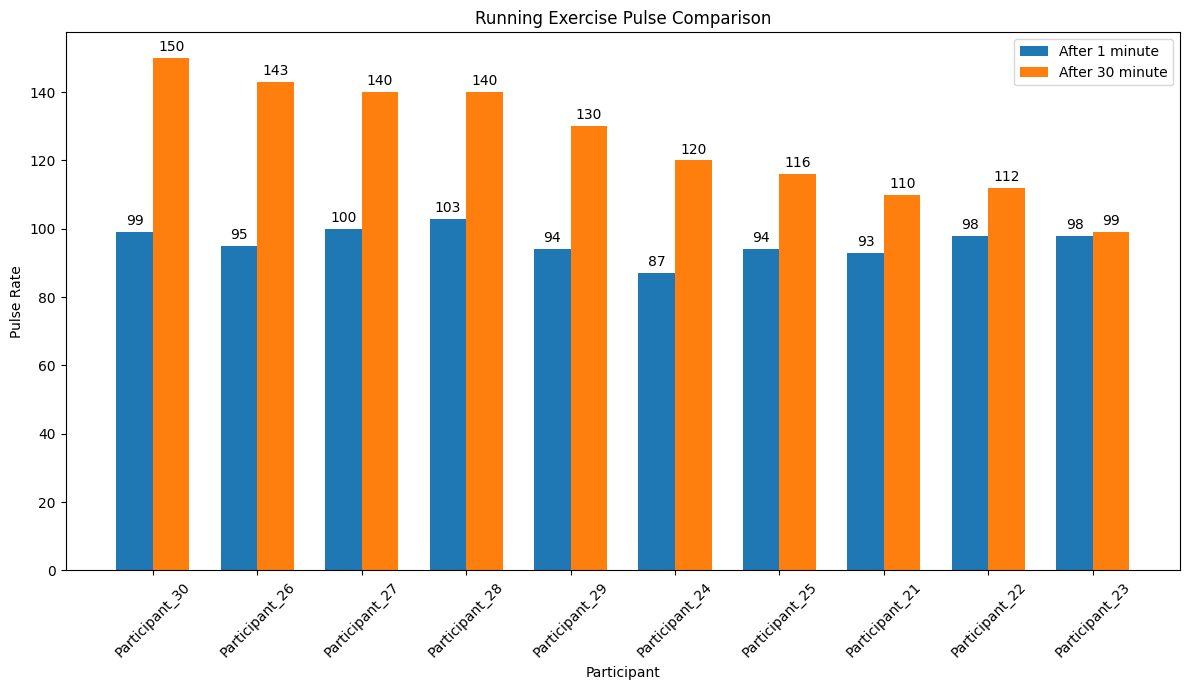

In [27]:
plt.figure(figsize=(12,7))

one_minute_bars = plt.bar(
    positions - bar_width / 2,
    chart_df["pulse_1_minute"],
    width=bar_width,
    label="After 1 minute"
)

thirty_minute_bars = plt.bar(
    positions + bar_width / 2,
    chart_df["pulse_30_minutes"],
    width=bar_width,
    label="After 30 minute"
)

plt.title("Running Exercise Pulse Comparison")
plt.xlabel("Participant")
plt.ylabel("Pulse Rate")


plt.xticks(
    positions,
    chart_df["participant"],
    rotation=45
)

plt.legend()

for bar in one_minute_bars:
    value = bar.get_height()
 
    plt.annotate(
        str(value),
        (
            bar.get_x() + bar.get_width() / 2,
            value
        ),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center"
    )


for bar in thirty_minute_bars:
    value = bar.get_height()
 
    plt.annotate(
        str(value),
        (
            bar.get_x() + bar.get_width() / 2,
            value
        ),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center"
    )

plt.tight_layout()
plt.show()